## Creating a Binary Classification Model for Detecting Fraudulent Transactions

### Overview
This notebook implements a binary classification pipeline to detect fraudulent transactions using the IEEE-CIS Fraud Detection dataset. The workflow is structured as follows:

1. **Feature Engineering**: Temporal extraction, D-column normalization, email grouping, categorical missing-value handling
2. **Preprocessing**: V-column missingness flags, sentinel/median imputation, splitting *before* encoding
3. **Encoding & Dimensionality Reduction**: Split-safe frequency encoding, split-safe label encoding, PCA on V-columns
4. **Modelling**: Decision Tree, Random Forest, and LightGBM with threshold tuning

### Attribution
The helper functions used in this notebook are adapted from the Kaggle notebook *"Extensive EDA and Modeling XGB + Hyperopt"* by kabure, available at: https://www.kaggle.com/code/kabure/extensive-eda-and-modeling-xgb-hyperopt

They were modified these functions to suit our dataset and analysis goals.

### Set-up and Helper Functions

In [42]:
from pathlib import Path
import datetime

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_recall_curve

In [43]:
BASE_DIR=Path('..')/'data'

train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
test_transaction = pd.read_csv(BASE_DIR/'test_transaction.csv')
train_identity = pd.read_csv(BASE_DIR/'train_identity.csv')
test_identity = pd.read_csv(BASE_DIR/'test_identity.csv')

In [44]:
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

# The test identity file uses hyphens (id-01) while train uses underscores (id_01).
# Normalize test columns so both datasets share the same naming convention.
df_test.columns = df_test.columns.str.replace('-', '_', regex=False)

# Clear memory (more memory is always better)
del train_transaction, test_transaction, train_identity, test_identity

In [45]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.helpers import (
    SummarizeTable,
    CalcOutliers,
    PCAFitTransform,
    detect_v_missingness_groups, # April 25: identifies V-column missingness blocks
    split_safe_frequency_encode, # April 25: frequency encoding on train only
    split_safe_label_encode # April 25: label encoding on train only
)

### Feature Engineering

#### Temporal Feature Engineering
After researching how to deal with the encoded temporal features, a few comments on the Kaggle discussion board confirmed that `TransactionDT` is a timedelta in seconds from a reference date ([Source](https://www.kaggle.com/c/ieee-fraud-detection/discussion/100400))

In [46]:
START_DATE = '2017-12-01' # Date specified 
startdate = datetime.datetime.strptime(START_DATE, '%Y-%m-%d')

for df in [df_train, df_test]:
    df['Hour'] = df['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)).hour)
    df['Weekday'] = df['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)).weekday())
    df['Day'] = df['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)).day)

#### D-columns normalization
During our EDA, we noticed that D9 has ~87% missingness in the raw data (515614 NAs to be exact). The normalization step (TransactionDT/86400 - D9) would not produce anything meaningful for this column since it's not actually in days, so D9 should be skipped in the normalization loop.

All other D-columns measure days since some reference event (For example, D1 = days since the card was first used). These values grow continuously over the dataset's timespan, meaning that two transactions from the same card at different points in time would have different D1 values even if the card behaviour is identical. Subtracting from the transaction day ($\frac{TransactionDT}{86400}$) converts each D-column into a fixed calendar reference point per client, removing this time drift and making the feature comparable across transactions.

In [47]:
d_columns = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']

for col in d_columns:
    if col in df_train.columns:
        # Converts seconds to days
        df_train.loc[:, col] = df_train['TransactionDT']/(24 * 60 * 60) - df_train[col]
        df_test.loc[:, col] = df_test['TransactionDT']/(24 * 60 * 60) - df_test[col]

# Drop TransactionDT after extracting temporal features and normalizing D-columns.
# Note: In a more advanced pipeline, TransactionDT could be retained to build velocity
# features (e.g., transactions per hour per card) and recency features (e.g., seconds
# since the last transaction on this card). These are strong fraud signals that winning
# competition solutions relied on heavily.
df_train.drop(columns=['TransactionDT'], inplace=True)
df_test.drop(columns=['TransactionDT'], inplace=True)

#### Email domain grouping

In [48]:
# Email Features
# Map raw email domains to provider groups (Google, Yahoo, Microsoft) and collapse rare domains into "Others".
google_domains = ['gmail.com', 'gmail']
yahoo_domains = ['yahoo.com', 'yahoo.com.mx', 'yahoo.co.uk', 'yahoo.co.jp', 'yahoo.de', 'yahoo.fr', 'yahoo.es']
microsoft_domains = ['hotmail.com', 'outlook.com', 'msn.com', 'live.com', 'hotmail.es', 'hotmail.co.uk', 'hotmail.de', 'outlook.es', 'live.com.mx', 'live.fr', 'hotmail.fr']

for col in ['P_emaildomain', 'R_emaildomain']:
    if col not in df_train.columns:
        continue

    # Lowercase everything just in case
    df_train.loc[:, col] = df_train[col].str.lower().str.strip()
    df_test.loc[:, col] = df_test[col].str.lower().str.strip()

    # Replace each domain with its provider name
    df_train.loc[df_train[col].isin(google_domains), col] = 'google'
    df_train.loc[df_train[col].isin(yahoo_domains), col] = 'yahoo'
    df_train.loc[df_train[col].isin(microsoft_domains), col] = 'microsoft'

    df_test.loc[df_test[col].isin(google_domains), col] = 'google'
    df_test.loc[df_test[col].isin(yahoo_domains), col] = 'yahoo'
    df_test.loc[df_test[col].isin(microsoft_domains), col] = 'microsoft'

    # Any domain appearing fewer than 500 times is too rare to be useful
    # Collapse them all into "Other"
    frequency = df_train[col].value_counts()
    rare_domains = frequency[frequency <= 500].index
    df_train.loc[df_train[col].isin(rare_domains), col] = 'other'
    df_test.loc[df_test[col].isin(rare_domains), col] = 'other'

    # Fill any missing values
    df_train.loc[:, col] = df_train[col].fillna('missing')
    df_test.loc[:, col] = df_test[col].fillna('missing')

#### Categorical missing values
In the original pipeline, categorical NaNs were filled with the most frequent value (mode) during imputation.
This is problematic: for a column like `DeviceType` (76% missing), it asserts that 76% of transactions
came from the most popular device, when the truth is "no identity data was collected."

Instead, we treat missingness as an explicit category (`'missing'`) so the model can learn that "data was unavailable" is different from any observed device type. This is consistent with how we already handled email domains above.

In [49]:
# Fill all remaining categorical NaN values with 'missing' as an explicit category.
# This replaces the old SimpleImputer(strategy='most_frequent') approach.
categorical_cols_all = df_train.select_dtypes(exclude=np.number).columns.tolist()

for col in categorical_cols_all:
    df_train[col] = df_train[col].fillna('missing')
    df_test[col] = df_test[col].fillna('missing')

print(f'Filled {len(categorical_cols_all)} categorical columns with explicit missing category')
print(f'Columns: {categorical_cols_all}')

Filled 31 categorical columns with explicit missing category
Columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


#### Log-Transforming TransactionAmt
In our EDA, `TransactionAmt` has a skew of around 14, and Log transform confirmed to reduce the skew and normalizes the distribution. `np.log1p` is used instead of `np.log` to handle zero values safely, because a log(0) is undefined.

In [50]:
df_train.loc[:, 'TransactionAmt'] = np.log1p(df_train['TransactionAmt'])
df_test.loc[:, 'TransactionAmt'] = np.log1p(df_test['TransactionAmt'])

### Pre-Processing

#### Handling column missingness
The original pipeline dropped every non-V column above 50% missing. This threw away all ID columns (most sit at 76% missing) even though they could carry fraud signal in the rows where they exist.

We now raise the threshold to 80%, keeping ID columns in the 50-80% range. Columns above 99% missing (id_07, id_08, id_21–id_27) are still dropped since there is almost no data to learn from.

In [51]:
# Separate V-columns (handled separately below)
v_columns = [c for c in df_train.columns if c.startswith('V')]
non_v_columns = [c for c in df_train.columns if not c.startswith('V') and c not in ('isFraud', 'TransactionID')]

# Raised from 0.5 to 0.8 
# Keeps ID columns in the 50-80% range
missingness_threshold = 0.8
kept_columns = df_train[non_v_columns].columns[df_train[non_v_columns].isnull().mean() <= missingness_threshold]

columns_final = list(kept_columns) + v_columns
df_train = df_train[['isFraud'] + columns_final]
df_test = df_test.reindex(columns=columns_final).copy()

print(f"Columns after missingness filter: {len(columns_final)}")

Columns after missingness filter: 412


#### V-column missingness groups
The V-columns (V1-V339) come from different data sources at Vesta and share grouped missingness if V1 is missing for a row, V2 through V11 are missing too. Rather than creating 339 binary flags (which would be redundant), we identify these natural groups and create one flag per group.

These flags go directly into the final feature set so the model can learn "this block of data was unavailable". The V-column values themselves are then imputed with the median for PCA, because PCA is a linear transformation that interprets extreme sentinel values as real variance, which would cause the first principal components to capture missingness patterns rather than actual transaction behaviour.

In [52]:
v_cols_present = [c for c in v_columns if c in df_train.columns]

# Detect groups of V-columns that share identical missingness patterns.
# Binary missingness flags are NOT learned statistics. They simply record whether a value was null. 
# Creating them before the split is equivalent to calling .isnull()
# on each row, which doesn't leak any cross-row information.
v_groups, v_flags_train = detect_v_missingness_groups(df_train, v_cols_present)
_, v_flags_test = detect_v_missingness_groups(df_test, v_cols_present)

print(f'Found {len(v_groups)} V-column missingness groups:')
for name, cols in v_groups.items():
    pct = df_train[cols[0]].isnull().mean() * 100
    print(f'  {name}: {len(cols)} columns ({pct:.1f}% missing) — {cols[0]}...{cols[-1]}')

Found 15 V-column missingness groups:
  v_missing_group_0: 11 columns (47.3% missing) — V1...V11
  v_missing_group_1: 23 columns (12.9% missing) — V12...V34
  v_missing_group_2: 18 columns (28.6% missing) — V35...V52
  v_missing_group_3: 22 columns (13.1% missing) — V53...V74
  v_missing_group_4: 20 columns (15.1% missing) — V75...V94
  v_missing_group_5: 43 columns (0.1% missing) — V95...V137
  v_missing_group_6: 18 columns (86.1% missing) — V138...V163
  v_missing_group_7: 11 columns (86.1% missing) — V143...V166
  v_missing_group_8: 31 columns (76.4% missing) — V167...V216
  v_missing_group_9: 19 columns (76.3% missing) — V169...V210
  v_missing_group_10: 46 columns (77.9% missing) — V217...V278
  v_missing_group_11: 16 columns (76.1% missing) — V220...V272
  v_missing_group_12: 32 columns (0.0% missing) — V279...V321
  v_missing_group_13: 11 columns (0.2% missing) — V281...V315
  v_missing_group_14: 18 columns (86.1% missing) — V322...V339


In [53]:
# Impute V-columns with median (neutral for PCA, no artificial variance)
# The missingness signal is already captured in the group flags above
v_imputer = SimpleImputer(strategy='median')
df_train[v_cols_present] = v_imputer.fit_transform(df_train[v_cols_present])
df_test[v_cols_present] = v_imputer.transform(df_test[v_cols_present])

#### D-column sentinel fill
After normalization, each D-column represents an approximate calendar date of a reference event. A missing value means the reference event never happened — the card was never used before, or the reference activity does not exist. This is categorically different from "the event happened on the median date," so we use a sentinel value (min - 1) that the tree can learn to split on.

In [54]:
# Sentinel fill for D-columns (tree-friendly, no PCA downstream)
d_cols_present = [c for c in d_columns if c in df_train.columns]

for col in d_cols_present:
    sentinel = df_train[col].min() - 1
    df_train[col] = df_train[col].fillna(sentinel)
    df_test[col] = df_test[col].fillna(sentinel)

#### Numerical missingness flags and imputation
For numerical columns with moderate missingness (above ~2%), we create binary flags before imputing with the median. This preserves the "data was unavailable" signal that median imputation would otherwise destroy. For columns with negligible missingness, median imputation alone is sufficient.

In [55]:
# Identify remaining numerical columns (excluding V-columns and D-columns, which were already handled)
numerical_remaining = (
    df_train
    .drop(columns=v_cols_present + d_cols_present + ['isFraud'], errors='ignore')
    .select_dtypes(include=np.number)
    .columns.tolist()
)

# Create binary flags for columns with >2% missingness.
# These are schema-level indicators (was data present or not), not learned statistics, so creating them before the split is safe. 
# It's equivalent to checking isnull().
flag_threshold = 0.02
flagged_cols = []

for col in numerical_remaining:
    miss_rate = df_train[col].isnull().mean()
    if miss_rate > flag_threshold:
        flag_name = f'{col}_missing'
        df_train[flag_name] = df_train[col].isnull().astype(int)
        df_test[flag_name] = df_test[col].isnull().astype(int)
        flagged_cols.append(col)

print(f'Created binary flags for {len(flagged_cols)} columns: {flagged_cols}')

# Now median-impute the remaining numerical NaN values
numerical_to_impute = df_train[numerical_remaining]
numerical_to_impute_test = df_test[numerical_remaining]

num_imputer = SimpleImputer(strategy='median')
df_train[numerical_remaining] = num_imputer.fit_transform(numerical_to_impute)
df_test[numerical_remaining] = num_imputer.transform(numerical_to_impute_test)

/var/folders/dv/8f4r5dp50yv_lywv_s27_ncw0000gn/T/ipykernel_29742/1317827111.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[flag_name] = df_train[col].isnull().astype(int)
/var/folders/dv/8f4r5dp50yv_lywv_s27_ncw0000gn/T/ipykernel_29742/1317827111.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test[flag_name] = df_test[col].isnull().astype(int)
/var/folders/dv/8f4r5dp50yv_lywv_s27_ncw0000gn/T/ipykernel_29742/1317827111.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

Created binary flags for 12 columns: ['addr1', 'addr2', 'dist1', 'id_01', 'id_02', 'id_05', 'id_06', 'id_11', 'id_13', 'id_17', 'id_19', 'id_20']


### Splitting the data
Change from original: the split now happens before frequency encoding, label encoding, and PCA. This ensures that all encoding statistics (frequencies, label mappings, PCA components) are derived exclusively from training data. In the original version, frequency maps were computed on the full dataset (including validation rows), which introduced subtle information leakage. Frequencies are correlated with fraud rates, so the model was receiving a signal derived partly from the rows it was being evaluated on.

Decision Trees do not need scaling! They split on thresholds not distances.

In [56]:
# Attach V-column missingness flags before splitting.
# Binary flags (was this value null?) are row-level observations, not learned
# statistics, so including them before the split does not leak information.
df_train = pd.concat([df_train, v_flags_train], axis=1)
df_test = pd.concat([df_test, v_flags_test], axis=1)

# Separate target before splitting
class_label = df_train['isFraud'].reset_index(drop=True)
df_train_features = df_train.drop(columns=['isFraud']).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_train_features,
    class_label,
    test_size=0.2,
    random_state=42,
    stratify=class_label
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (472432, 439), X_test: (118108, 439)


### Encoding
All encoding steps below are fitted on `X_train` only and then applied to `X_test`. This mirrors a real deployment setting where you only have historical data at encoding time.

#### Frequency Encoding
`card1`, `card2`, and `card5` have thousands of unique values, which leads `get_dummies` to create thousands of columns. That is way too many for a Decision Tree. Instead, we replaced each value with how often it appears in the training data only. For example, a card appearing 50000 times is likely a legitimate repeat customer, whilst a card appearing 3 times is suspicious.

Test-set values unseen during training receive frequency 0.

In [57]:
frequency_columns = ['card1', 'card2', 'card5', 'addr1', 'addr2']

# Only columns that survived the missingness filter
frequency_columns = [c for c in frequency_columns if c in X_train.columns]

# Frequency maps are computed from X_train only (no leakage)
X_train, X_test = split_safe_frequency_encode(X_train, X_test, frequency_columns)

#### Label Encoding
We avoid `get_dummies` here as it creates too many columns for high-cardinality features. LabelEncoder converts each category to an integer ('google' to 0, 'microsoft' to 1). Decision Trees handle label-encoded categories well since they split on thresholds.

Change from original: the encoder is now fitted on training data only. Unseen categories in the test set are mapped to a dedicated 'unknown' integer (max_label + 1), which is how a production pipeline would handle a new category it has never encountered.

In [58]:
# Identify categorical columns that still need encoding
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Ensure consistent dtype before encoding
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# Fit on train only, unseen test categories get an 'unknown' label
X_train, X_test, encoders = split_safe_label_encode(X_train, X_test, categorical_cols)

print(f'Encoded {len(categorical_cols)} categorical columns: {categorical_cols}')

Encoded 31 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


### Dimensionality Reduction (PCA on V-columns)
Instead of hardcoding `n_components=30`, we now select the number of components that explain at least 95% of the variance. This makes the choice data-driven rather than arbitrary, and documents exactly how much information is retained.

In [59]:
pca_columns = [c for c in v_cols_present if c in X_train.columns]

# Scale V-columns to [0, 1] before PCA
scaler = MinMaxScaler(feature_range=(0, 1))
X_train[pca_columns] = scaler.fit_transform(X_train[pca_columns])
X_test[pca_columns] = scaler.transform(X_test[pca_columns])

# First, fit full PCA to inspect explained variance
pca_full = PCA(random_state=4)
pca_full.fit(X_train[pca_columns])

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f'Components needed for 95% variance: {n_components_95}')
print(f'Variance explained by first 30 components: {cumulative_var[29]:.4f}')
print(f'Variance explained by {n_components_95} components: {cumulative_var[n_components_95-1]:.4f}')

Components needed for 95% variance: 46
Variance explained by first 30 components: 0.9178
Variance explained by 46 components: 0.9510


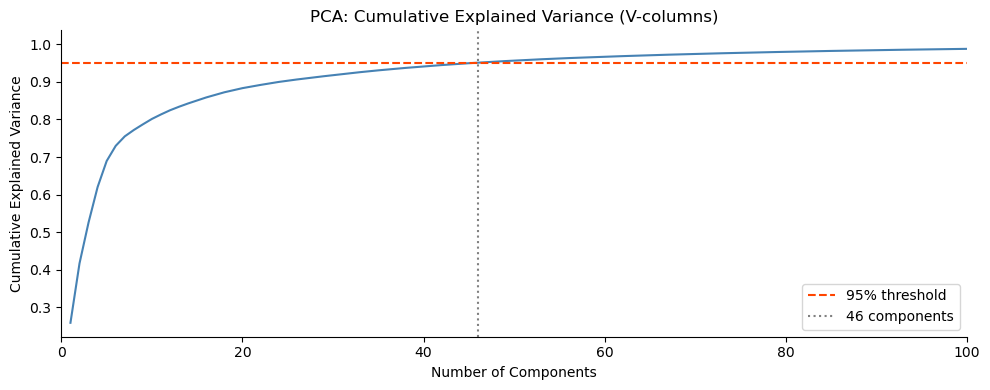

In [60]:
# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, color='steelblue')
ax.axhline(0.95, color='orangered', linestyle='dashed', label='95% threshold')
ax.axvline(n_components_95, color='grey', linestyle='dotted', label=f'{n_components_95} components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA: Cumulative Explained Variance (V-columns)')
ax.legend()
ax.set_xlim(0, 100)  # Zoom in on the meaningful range
sns.despine()
plt.tight_layout()
plt.show()

In [61]:
# Apply PCA with the data-driven component count
pca = PCA(n_components=n_components_95, random_state=4)

train_pca = pca.fit_transform(X_train[pca_columns])
test_pca = pca.transform(X_test[pca_columns])

# Convert to DataFrame and attach
pca_col_names = [f'PCA_V_{i}' for i in range(n_components_95)]
train_pca_df = pd.DataFrame(train_pca, columns=pca_col_names, index=X_train.index)
test_pca_df = pd.DataFrame(test_pca, columns=pca_col_names, index=X_test.index)

# Drop original V-columns and replace with PCA components
X_train = X_train.drop(columns=pca_columns)
X_test = X_test.drop(columns=pca_columns)

X_train = pd.concat([X_train, train_pca_df], axis=1)
X_test = pd.concat([X_test, test_pca_df], axis=1)

print(f'Feature count after PCA: {X_train.shape[1]}')

Feature count after PCA: 146


In [62]:
# Sanity check: verify train and test have identical columns in the same order
assert list(X_train.columns) == list(X_test.columns), 'Column mismatch between train and test!'
assert X_train.isnull().sum().sum() == 0, f'Train still has {X_train.isnull().sum().sum()} NaN values'
assert X_test.isnull().sum().sum() == 0, f'Test still has {X_test.isnull().sum().sum()} NaN values'

print(f'Final feature matrix: {X_train.shape[1]} features, {X_train.shape[0]} training rows')
print('No NaN values remain. Column order matches between train and test.')

Final feature matrix: 146 features, 472432 training rows
No NaN values remain. Column order matches between train and test.


### Modelling

#### Decision Tree
`class_weight='balanced'` handles the class imbalance: it automatically adjusts the weight of each class inversely proportional to its frequency. This means the model penalizes missing a fraud (FN) more than a false alarm (FP), which in turn achieves the goal of balancing the scales without altering the actual data. In earlier project iterations, we used SMOTE, which works by finding a minority class point and its nearest neighbors (`k_neighbours=5` by default), and drawing a line between them to create a synthetic data point. ([Source](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/)).

Initially, by using Youden's J, the optimal threshold was statistically determined to achieve a good balance between precision and recall. For our Decision Tree, lowering the threshold manually trades some precision for a better recall ([Source](https://scikit-learn.org/stable/modules/classification_threshold.html)). Usually, for fraud detection, missing a fraud (FN) is far worse than a false alarm (FP). It optimized the model based on the ROC Curve, which looks at the True Positive Rate and the False Positive Rate. In a massive, imbalanced dataset like this (where 96.5% of the data is "Not Fraud"), the True Negative pile is absolutely enormous. Because of this, the model can accidentally flag 10000 innocent customers as "Fraud" (False Positives), and the ROC curve barely registers it as a penalty. Youden's J will happily sacrifice thousands of innocent customers just to catch 10 more fraudsters.

Solution was to switch to Precision-Recall Tuning.

Running `'clf.predict_proba(X_test)'`, the Decision Tree does not actually predict if a transaction is "Fraud" or "Not Fraud". Instead, it outputs a percentage of suspicion.

In [63]:
# Initialize and train the hardcoded Decision Tree
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=67,
    class_weight='balanced',
    max_depth=12,
    min_samples_leaf=50
)

clf_dt.fit(X_train, y_train)

# Generate probabilities on the test set
y_proba_dt = clf_dt.predict_proba(X_test)[:, 1]

# Tune threshold with max F1-Score
precisions_dt, recalls_dt, thresholds_pr_dt = precision_recall_curve(y_test, y_proba_dt)

# Calculate F1 for all thresholds (Adding 1e-8 prevents division-by-zero)
f1_scores_dt = (2 * precisions_dt[:-1] * recalls_dt[:-1]) / (precisions_dt[:-1] + recalls_dt[:-1] + 1e-8)

# Find the threshold that yields the absolute best F1-Score
best_threshold_dt = thresholds_pr_dt[f1_scores_dt.argmax()]

# Apply the optimal threshold
clf_pred_dt = (y_proba_dt >= best_threshold_dt).astype(int)

print(f"Decision Tree Optimal threshold (Max F1): {best_threshold_dt:.4f}")
print(classification_report(y_test, clf_pred_dt))

Decision Tree Optimal threshold (Max F1): 0.9258
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.62      0.45      0.52      4133

    accuracy                           0.97    118108
   macro avg       0.80      0.72      0.75    118108
weighted avg       0.97      0.97      0.97    118108



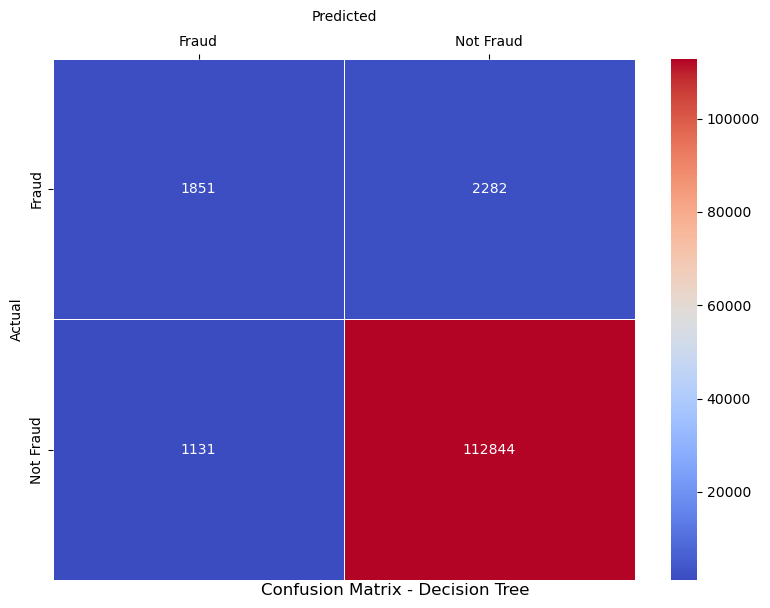

In [64]:
cm_dt = confusion_matrix(y_test, clf_pred_dt, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_dt, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')
fig.text(0.5, 0.00, 'Confusion Matrix - Decision Tree', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [65]:
# Compute feature importance
feature_importance = pd.Series(clf_dt.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Print the features that the tree relied on the most
print("Top 20 features:")
print(feature_importance.head(20))

Top 20 features:
PCA_V_1           0.189555
PCA_V_4           0.136481
C1                0.069077
C14               0.060596
PCA_V_10          0.040863
TransactionAmt    0.034381
D1                0.032178
D2                0.025210
C2                0.023388
card1             0.022299
D15               0.016587
card6             0.016371
C13               0.015748
card2             0.013591
PCA_V_17          0.011246
C6                0.011059
P_emaildomain     0.009998
PCA_V_21          0.008599
D10               0.008421
PCA_V_18          0.008385
dtype: float64


#### Random Forest

In [66]:
clf_rf = RandomForestClassifier(
    n_estimators=100, # Builds 100 independent trees
    max_depth=15,  # Captures complex patterns
    class_weight='balanced', 
    random_state=67,
    n_jobs=-1
)

clf_rf.fit(X_train, y_train)

# Generate probabilities on the test set
y_proba_rf = clf_rf.predict_proba(X_test)[:, 1]

# Tune threshold with max F1-Score
precisions_rf, recalls_rf, thresholds_pr_rf = precision_recall_curve(y_test, y_proba_rf)

# Calculate F1 for all thresholds
f1_scores_rf = (2 * precisions_rf[:-1] * recalls_rf[:-1]) / (precisions_rf[:-1] + recalls_rf[:-1] + 1e-8)

# Find the threshold that yields the absolute best F1-Score
best_threshold_rf = thresholds_pr_rf[f1_scores_rf.argmax()]

# Apply the winning threshold
clf_pred_rf = (y_proba_rf >= best_threshold_rf).astype(int)

# Print the final results
print(f"Random Forest Optimal threshold (Max F1): {best_threshold_rf:.4f}")
print(classification_report(y_test, clf_pred_rf))

Random Forest Optimal threshold (Max F1): 0.5972
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.66      0.57      0.61      4133

    accuracy                           0.97    118108
   macro avg       0.82      0.78      0.80    118108
weighted avg       0.97      0.97      0.97    118108



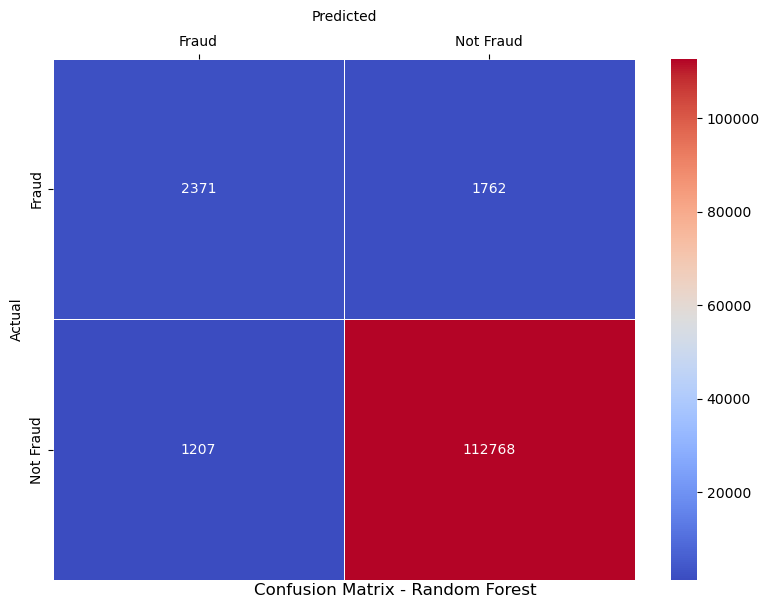

In [67]:
cm_rf = confusion_matrix(y_test, clf_pred_rf, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')
fig.text(0.5, 0.00, 'Confusion Matrix - Random Forest', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

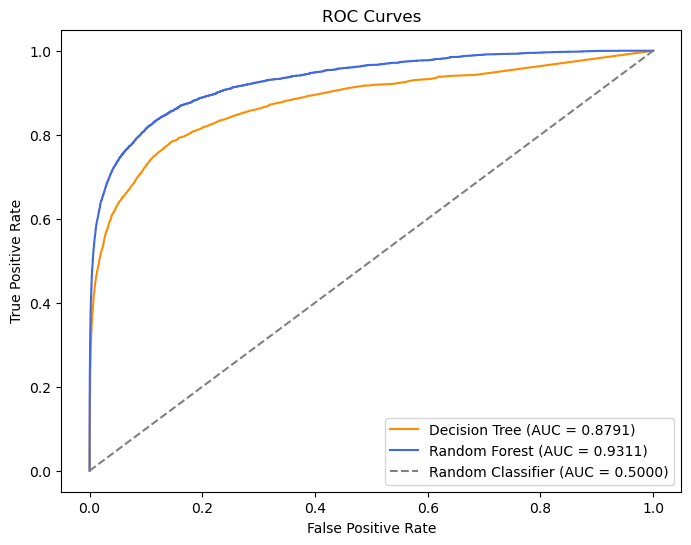

In [68]:
# Collect all models in one list so the loop handles any number of models cleanly
models_roc = [
    ('Decision Tree', y_proba_dt, 'darkorange'),
    ('Random Forest', y_proba_rf, 'royalblue'),
]

fig, ax = plt.subplots(figsize=(8, 6))

# ROC curves
for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc_score:.4f})')

ax.plot([0, 1], [0, 1], color='grey', linestyle='dashed', label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

In [69]:
# Display thresholds side by side
optimal_thresholds = {
    'Decision Tree': best_threshold_dt,
    'Random Forest': best_threshold_rf,
}

print('Optimal Thresholds (Max F1)')

for name, thresh in optimal_thresholds.items():
    print(f'{name:<20}: {thresh:.4f}')
print('LightGBM : computed in next cell')

Optimal Thresholds (Max F1)
Decision Tree       : 0.9258
Random Forest       : 0.5972
LightGBM : computed in next cell


### LightGBM

LightGBM is a gradient boosting framework that uses tree based learning algorithms. It is designed to be distributed and efficient with the following advantages:
- Faster training speed and higher efficiency.
- Lower memory usage.
- Better accuracy.
- Support of parallel, distributed, and GPU learning.
- Capable of handling large-scale data.

In [70]:
from lightgbm import LGBMClassifier

# Ensure all columns are numeric (PCA concat can re-introduce object dtypes)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Initialize and train the LightGBM Classifier
clf_lgb = LGBMClassifier(
    n_estimators=500,        
    learning_rate=0.05,      
    max_depth=8,             
    class_weight='balanced', 
    random_state=67,
    n_jobs=-1                
)

clf_lgb.fit(X_train, y_train)

# Generate probabilities on the test set
y_proba_lgb = clf_lgb.predict_proba(X_test)[:, 1]

# THRESHOLD TUNING (Max F1-Score)
precisions_lgb, recalls_lgb, thresholds_pr_lgb = precision_recall_curve(y_test, y_proba_lgb)

# Calculate F1 for all thresholds
f1_scores_lgb = (2 * precisions_lgb[:-1] * recalls_lgb[:-1]) / (precisions_lgb[:-1] + recalls_lgb[:-1] + 1e-8)

# Find the threshold that yields the absolute best F1-Score
best_threshold_lgb_f1 = thresholds_pr_lgb[f1_scores_lgb.argmax()]

# Apply the winning threshold
clf_pred_lgb = (y_proba_lgb >= best_threshold_lgb_f1).astype(int)

# Print the final results
print(f"LightGBM Optimal threshold (Max F1): {best_threshold_lgb_f1:.4f}")
print(classification_report(y_test, clf_pred_lgb))

LightGBM Optimal threshold (Max F1): 0.8195
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.70      0.60      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.84      0.79      0.82    118108
weighted avg       0.98      0.98      0.98    118108



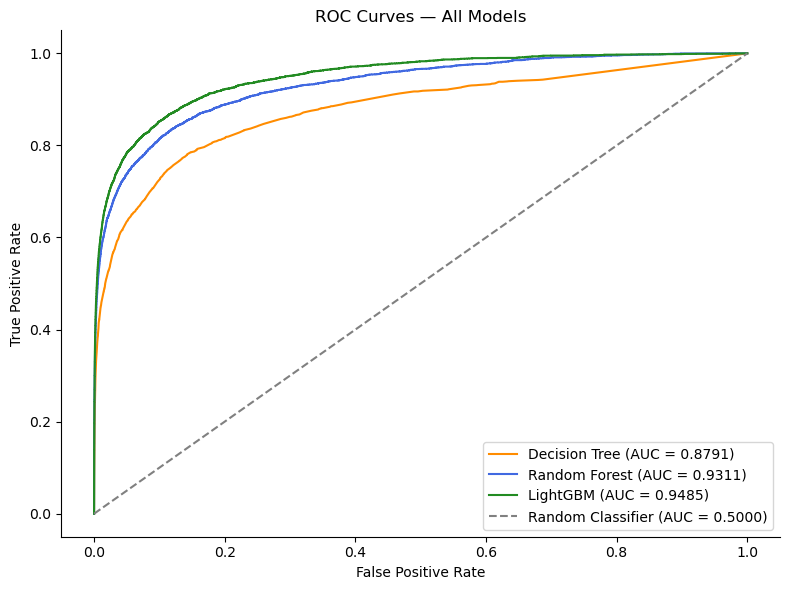

In [71]:
# Final ROC comparison with all three models
models_roc_all = [
    ('Decision Tree', y_proba_dt, 'darkorange'),
    ('Random Forest', y_proba_rf, 'royalblue'),
    ('LightGBM', y_proba_lgb, 'forestgreen'),
]

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in models_roc_all:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc_score:.4f})')

ax.plot([0, 1], [0, 1], color='grey', linestyle='dashed', label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

([Source](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html))

In [72]:
import optuna
from sklearn.model_selection import StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        # Core complexity (official guide: num_leaves < 2^max_depth)
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        
        # Regularization
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        
        # Stochastic training
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),
        
        # Learning
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': 1000,  # High ceiling: early stopping decides the real count
        
        # Fixed
        'class_weight': 'balanced',
        'random_state': 67,
        'n_jobs': -1,
        'verbose': -1,
    }
    
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = LGBMClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        y_val_proba = model.predict_proba(X_fold_val)[:, 1]
        scores.append(roc_auc_score(y_fold_val, y_val_proba))
    
    return np.mean(scores)

import lightgbm as lgb

study = optuna.create_study(direction='maximize', study_name='lgbm_fraud')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest AUC: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


Best AUC: 0.9525
Best params:
  num_leaves: 140
  max_depth: 10
  min_child_samples: 111
  reg_alpha: 0.3243479107645532
  reg_lambda: 2.839904020462429
  subsample: 0.8983565046853005
  colsample_bytree: 0.8421176818109661
  subsample_freq: 6
  learning_rate: 0.04040497462803735


In [73]:
# Retrain on full X_train with best params and early stopping on a held-out slice
best_params = study.best_params
best_params.update({
    'n_estimators': 1000,
    'class_weight': 'balanced',
    'random_state': 67,
    'n_jobs': -1,
    'verbose': -1,
})

clf_lgb = LGBMClassifier(**best_params)
clf_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

print(f'Best iteration: {clf_lgb.best_iteration_}')

# Threshold tuning
y_proba_lgb = clf_lgb.predict_proba(X_test)[:, 1]
precisions_lgb, recalls_lgb, thresholds_pr_lgb = precision_recall_curve(y_test, y_proba_lgb)
f1_scores_lgb = (2 * precisions_lgb[:-1] * recalls_lgb[:-1]) / (precisions_lgb[:-1] + recalls_lgb[:-1] + 1e-8)
best_threshold_lgb_f1 = thresholds_pr_lgb[f1_scores_lgb.argmax()]
clf_pred_lgb = (y_proba_lgb >= best_threshold_lgb_f1).astype(int)

print(f"\nLightGBM Optimal threshold (Max F1): {best_threshold_lgb_f1:.4f}")
print(classification_report(y_test, clf_pred_lgb))

Best iteration: 1000

LightGBM Optimal threshold (Max F1): 0.7315
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.85      0.72      0.78      4133

    accuracy                           0.99    118108
   macro avg       0.92      0.86      0.89    118108
weighted avg       0.99      0.99      0.99    118108

